In [104]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import xgboost as xgb

import joblib

In [105]:
df = pd.read_csv("claims_preprocessed_v3.csv")

print(df.columns.tolist())

['Claim_Form_Type', 'Provider_Specialty', 'Payer', 'Place_of_Service_Code', 'Place_of_Service_Desc', 'Diagnosis_Code', 'Procedure_Code', 'Procedure_Desc', 'Modifier_Code', 'Billed_Amount', 'Service_Date', 'Claim_Submission_Date', 'Payer_Timely_Filing_Limit_Days', 'Prior_Auth_Required', 'Prior_Auth_Obtained', 'Eligibility_Verified', 'Duplicate_Claim_Flag', 'NCCI_Bundling_Flag', 'Clearinghouse_Validation_Passed', 'Provider_Monthly_Claim_Volume', 'Provider_Payer_Prior_Denial_Count', 'Chronic_Condition_Flag', 'Claim_Status', 'CARC_Code', 'Denial_Reason', 'Service_Month', 'Submission_Month', 'Service_DayOfWeek', 'Submission_DayOfWeek', 'Claim_Submission_Delay']


In [106]:
denied_df = df[df["Claim_Status"] == "Denied"].copy()

print("Denied Claims :", denied_df.shape[0])

Denied Claims : 2710


## Verify Missing CARC Codes

In [107]:
print("Missing CARC Codes :", denied_df["CARC_Code"].isna().sum())

Missing CARC Codes : 0


## Explore CARC Distribution

In [108]:
carc_counts = denied_df["CARC_Code"].value_counts()

print(carc_counts)

CARC_Code
CO-45     1173
CO-50      419
CO-97      253
CO-197     240
CO-109     233
CO-16      195
CO-29      101
CO-18       96
Name: count, dtype: int64


## Visualize CARC Distribution

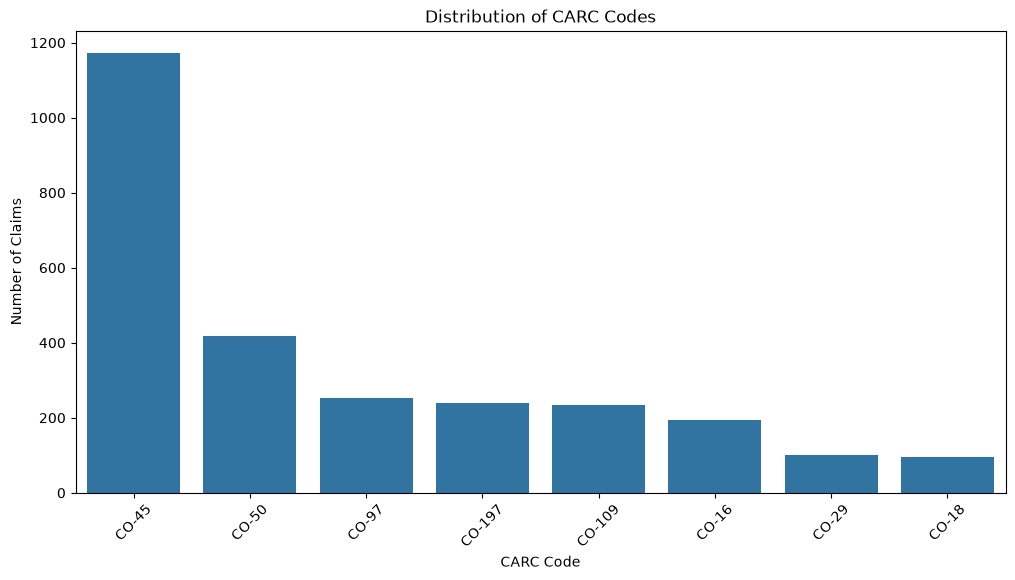

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    data=denied_df,
    x="CARC_Code",
    order=denied_df["CARC_Code"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribution of CARC Codes")

plt.xlabel("CARC Code")

plt.ylabel("Number of Claims")

plt.show()

## Encode CARC Codes

In [110]:
carc_encoder = LabelEncoder()

denied_df["CARC_Label"] = carc_encoder.fit_transform(
    denied_df["CARC_Code"]
)

print("Encoded CARC Classes:")
print(carc_encoder.classes_)

Encoded CARC Classes:
['CO-109' 'CO-16' 'CO-18' 'CO-197' 'CO-29' 'CO-45' 'CO-50' 'CO-97']


## Feature Selectio

In [111]:
X_carc = denied_df.drop(columns=[
    "Claim_Status",
    "CARC_Code",
    "CARC_Label",
    "Denial_Reason",
    "Procedure_Desc",
    "Place_of_Service_Desc",
    "Service_Date",
    "Claim_Submission_Date"
])

y_carc = denied_df["CARC_Label"]

print("Feature Shape :", X_carc.shape)
print("Target Shape  :", y_carc.shape)

Feature Shape : (2710, 23)
Target Shape  : (2710,)


## Train/Test Split

In [112]:
X_train_carc, X_test_carc, y_train_carc, y_test_carc = train_test_split(
    X_carc,
    y_carc,
    test_size=0.20,
    random_state=42,
    stratify=y_carc
)

print("Training Features :", X_train_carc.shape)
print("Testing Features  :", X_test_carc.shape)

Training Features : (2168, 23)
Testing Features  : (542, 23)


## T rain XGBoost Model

In [113]:
carc_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(carc_encoder.classes_),
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

carc_model.fit(X_train_carc, y_train_carc)

print("CARC Prediction Model trained successfully.")

CARC Prediction Model trained successfully.


In [114]:
y_pred_carc = carc_model.predict(X_test_carc)

accuracy = accuracy_score(y_test_carc, y_pred_carc)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6863


In [115]:
print(classification_report(
    y_test_carc,
    y_pred_carc,
    target_names=carc_encoder.classes_
))

              precision    recall  f1-score   support

      CO-109       0.68      0.72      0.70        47
       CO-16       0.56      0.51      0.53        39
       CO-18       0.69      0.95      0.80        19
      CO-197       0.56      0.75      0.64        48
       CO-29       0.67      0.60      0.63        20
       CO-45       0.85      0.69      0.76       234
       CO-50       0.55      0.63      0.59        84
       CO-97       0.60      0.73      0.65        51

    accuracy                           0.69       542
   macro avg       0.64      0.70      0.66       542
weighted avg       0.71      0.69      0.69       542



In [116]:
joblib.dump(carc_model, "carc_prediction_model.pkl")
joblib.dump(carc_encoder, "carc_label_encoder.pkl")

print("CARC Prediction Model saved successfully.")
print("CARC Label Encoder saved successfully.")
joblib.dump(X_test_carc, "X_test_carc.pkl")
joblib.dump(y_test_carc, "y_test_carc.pkl")

print("CARC test split saved successfully.")

CARC Prediction Model saved successfully.
CARC Label Encoder saved successfully.
CARC test split saved successfully.
